## Examen Restaurantes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import ctg_viz

### Ingeniería de Datos

In [2]:
users = pd.read_csv('datos/users.csv')
usercuisine = pd.read_csv('datos/usercuisine.csv')
ratings = pd.read_csv('datos/ratings.csv')
restaurants = pd.read_csv('datos/restaurants.csv')
hours = pd.read_csv('datos/hours.csv')
cuisines = pd.read_csv('datos/cuisine.csv')
payment_methods = pd.read_csv('datos/payment_methods.csv')
parking = pd.read_csv('datos/parking.csv')
users.head()


,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,birth_year,interest,personality,religion,activity,color,weight,budget,height
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,1989,variety,thrifty-protector,none,student,black,69,medium,1.77
1,U1002,22.150087,-100.983325,false,abstemious,informal,family,public,single,independent,1990,technology,hunter-ostentatious,Catholic,student,red,40,low,1.87
2,U1003,22.119847,-100.946527,false,social drinker,formal,family,public,single,independent,1989,none,hard-worker,Catholic,student,blue,60,low,1.69
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,1940,variety,hard-worker,none,professional,green,44,medium,1.53
4,U1005,22.183477,-100.959891,false,abstemious,no preference,family,public,single,independent,1992,none,thrifty-protector,Catholic,student,black,65,medium,1.69


### Análisis users

In [3]:
#users.budget = users.budget.map({'low': 1, 'medium': 2, 'high': 3, '?': 0})
users['age'] = 2025 - users['birth_year']

In [4]:
users_cuisine = users.join(usercuisine.set_index('userID'), on='userID')
users_cuisine[:10]

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,...,interest,personality,religion,activity,color,weight,budget,height,age,Rcuisine
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,variety,thrifty-protector,none,student,black,69,medium,1.77,36,American
1,U1002,22.150087,-100.983325,false,abstemious,informal,family,public,single,independent,...,technology,hunter-ostentatious,Catholic,student,red,40,low,1.87,35,Mexican
2,U1003,22.119847,-100.946527,false,social drinker,formal,family,public,single,independent,...,none,hard-worker,Catholic,student,blue,60,low,1.69,36,Mexican
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Bakery
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Breakfast-Brunch
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Japanese
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Contemporary
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Mexican
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Bagels
3,U1004,18.867000,-99.183000,false,abstemious,informal,family,public,single,independent,...,variety,hard-worker,none,professional,green,44,medium,1.53,85,Cafe-Coffee_Shop


In [5]:
users_ratings = users.join(ratings.set_index('userID'), on='userID')
users_ratings[:5]

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,...,activity,color,weight,budget,height,age,placeID,rating,food_rating,service_rating
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,medium,1.77,36,132830,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,medium,1.77,36,132825,2,2,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,medium,1.77,36,135085,0,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,medium,1.77,36,135040,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,student,black,69,medium,1.77,36,135039,1,1,1


In [6]:
users_ratings['frequency'] =users_ratings.groupby(['userID','placeID'])['rating'].transform('count')
users_ratings = users_ratings.rename(columns={'longitude':'longitude_user','latitude':'latitude_user'})
    
users_ratings.head()

,userID,latitude_user,longitude_user,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,...,color,weight,budget,height,age,placeID,rating,food_rating,service_rating,frequency
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,medium,1.77,36,132830,1,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,medium,1.77,36,132825,2,2,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,medium,1.77,36,135085,0,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,medium,1.77,36,135040,1,1,1,1
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,black,69,medium,1.77,36,135039,1,1,1,1


In [7]:
df = users_ratings.join(restaurants.set_index('placeID'), on='placeID').head()

In [8]:
from geopy.distance import geodesic

df['dist_km'] = df.apply(lambda row: geodesic((row.latitude_user, row.longitude_user), 
                                              (row.latitude, row.longitude)).kilometers, axis=1)
df.head()

,userID,latitude_user,longitude_user,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,...,smoking_area,dress_code,accessibility,price,url,Rambience,franchise,area,other_services,dist_km
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,none,informal,completely,low,?,familiar,f,closed,none,4.203769
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,none,informal,completely,low,?,familiar,f,open,none,0.930770
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,not permitted,informal,no_accessibility,medium,?,familiar,f,closed,none,1.261535
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,none,informal,no_accessibility,high,?,familiar,f,closed,none,1.056110
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,...,section,informal,no_accessibility,low,?,familiar,f,closed,none,0.768673


In [9]:
df.dtypes

userID               object
latitude_user       float64
longitude_user      float64
smoker               object
drink_level          object
dress_preference     object
ambience             object
transport            object
marital_status       object
hijos                object
birth_year            int64
interest             object
personality          object
religion             object
activity             object
color                object
weight                int64
budget               object
height              float64
age                   int64
placeID               int64
rating                int64
food_rating           int64
service_rating        int64
frequency             int64
latitude            float64
longitude           float64
the_geom_meter       object
name                 object
address              object
city                 object
state                object
country              object
fax                  object
zip                  object
alcohol             

In [10]:
df.corr(numeric_only=True)

,latitude_user,longitude_user,birth_year,weight,height,age,placeID,rating,food_rating,service_rating,frequency,latitude,longitude,dist_km
latitude_user,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
longitude_user,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
birth_year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
placeID,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,-0.654937,-0.613446,NaN,NaN,-0.429463,-0.442655,-0.581558
rating,NaN,NaN,NaN,NaN,NaN,NaN,-0.654937,1.000000,0.790569,NaN,NaN,-0.192874,-0.008172,-0.081089
food_rating,NaN,NaN,NaN,NaN,NaN,NaN,-0.613446,0.790569,1.000000,NaN,NaN,0.114611,-0.409938,-0.276534
service_rating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


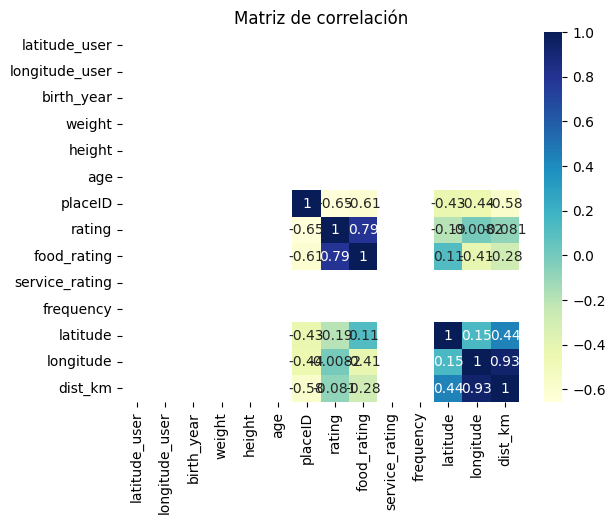

In [11]:
# Matriz de correlación
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="YlGnBu")
plt.title("Matriz de correlación")
plt.show()

### Análisis restaurantes

In [12]:
#Nuevas variiables (meadias de rating, numero de opciones de cocina y pago)
ratings_mean = ratings.groupby('placeID')[['rating','food_rating','service_rating']].mean()
rest_rating = restaurants.join(ratings_mean, on='placeID').rename(columns={'rating':'rating_mean',
                                                                           'food_rating':'food_rating_mean',
                                                                           'service_rating':'service_rating_mean'})
#Número de reseñas
ratings_count = ratings.groupby('placeID')['rating'].count()
rest_rating = rest_rating.join(ratings_count, on='placeID').rename(columns={'rating':'ratings_count'})

#Opciones de cocina
cuisines = cuisines.groupby('placeID')['Rcuisine'].count()
rest_rating = rest_rating.join(cuisines, on='placeID').rename(columns={'Rcuisine':'cuisines_options'})

#Opciones de pago
payment_options = payment_methods.groupby('placeID')['Rpayment'].count()
rest_rating = rest_rating.join(payment_options, on='placeID').rename(columns={'Rpayment': 'payment_options'})

#join con ratings originales
rest_rating = rest_rating.join(ratings.set_index('placeID'), on='placeID')
rest_rating = rest_rating.join(parking.set_index('placeID'), on='placeID')
rest_rating.head()

,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,...,food_rating_mean,service_rating_mean,ratings_count,cuisines_options,payment_options,userID,rating,food_rating,service_rating,parking_lot
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,5,1.0,NaN,U1093,2,2,2,none
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,5,1.0,NaN,U1066,1,1,1,none
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,5,1.0,NaN,U1040,1,1,1,none
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,5,1.0,NaN,U1110,2,2,2,none
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,5,1.0,NaN,U1121,2,2,2,none


In [13]:
#Mapear variables categóricas a discretas
rest_rating['price'] = rest_rating.price.map({'low': 1, 'medium': 2, 'high': 3})
rest_rating['franchise'] = rest_rating.franchise.map({'t': 0, 'f': 1})
rest_rating['parking'] = rest_rating.parking_lot.apply(lambda val: 0 if val == 'none' else 1)

#### Target

In [20]:
rest_rating["ratings_count"].mode()

0    4
Name: ratings_count, dtype: int64

In [ ]:
# se crea variable popular, para identificar los restaurantes que son más visitados
# de acuerdo al número de reseñas que tiene
rest_rating['popular'] = (rest_rating["ratings_count"] > rest_rating["ratings_count"].median()).astype(int)

In [39]:
rest_rating.groupby('placeID')['rating_mean'].mean().mean()

np.float64(1.1796215584942962)

In [37]:
rest_rating['rating_mean'].mean()

np.float64(1.1998277347114557)

In [44]:
# se crea la variable good_restaurant, para identificar los restaurantes con buena calificación
rest_rating["good_restaurant"] = (rest_rating["rating_mean"] > rest_rating["rating_mean"].mean().mean()).astype(int)
rest_rating.head()

,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,...,cuisines_options,payment_options,userID,rating,food_rating,service_rating,parking_lot,parking,popular,good_restaurant
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.0,NaN,U1093,2,2,2,none,0,0,1
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.0,NaN,U1066,1,1,1,none,0,0,1
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.0,NaN,U1040,1,1,1,none,0,0,1
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.0,NaN,U1110,2,2,2,none,0,0,1
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.0,NaN,U1121,2,2,2,none,0,0,1


In [45]:
rest_rating.groupby('placeID')['rating'].count().sort_values(ascending=False).head(50)

placeID
135085    36
132825    32
135032    28
135052    25
132834    25
135038    24
135060    22
135062    21
135042    20
132862    18
135058    18
132921    17
135041    17
135064    17
135079    17
135057    15
132572    15
135025    15
135028    15
135051    14
132856    14
135076    13
132754    13
135075    13
135045    13
135030    12
132872    12
135069    12
135039    12
132830    12
132723    12
135066    12
135081    11
135108    11
135026    11
135046    11
132733    10
135106    10
132951    10
135054    10
135047    10
135086    10
132768    10
135065     9
135043     9
135071     9
132954     9
135059     9
135021     9
134996     9
Name: rating, dtype: int64

In [43]:
rest_rating[rest_rating['good_restaurant'] == 0].head(20)

,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,...,cuisines_options,payment_options,userID,rating,food_rating,service_rating,parking_lot,parking,popular,good_restaurant
4,132613,23.752903,-99.165076,0101000020957F00008EBA2D06DC8157C194E03B7B504E...,carnitas_mata,lic. Emilio portes gil,victoria,Tamaulipas,Mexico,?,...,1.0,1.0,U1103,2,2,2,yes,1,0,0
4,132613,23.752903,-99.165076,0101000020957F00008EBA2D06DC8157C194E03B7B504E...,carnitas_mata,lic. Emilio portes gil,victoria,Tamaulipas,Mexico,?,...,1.0,1.0,U1070,1,1,0,yes,1,0,0
4,132613,23.752903,-99.165076,0101000020957F00008EBA2D06DC8157C194E03B7B504E...,carnitas_mata,lic. Emilio portes gil,victoria,Tamaulipas,Mexico,?,...,1.0,1.0,U1082,0,0,0,yes,1,0,0
4,132613,23.752903,-99.165076,0101000020957F00008EBA2D06DC8157C194E03B7B504E...,carnitas_mata,lic. Emilio portes gil,victoria,Tamaulipas,Mexico,?,...,1.0,1.0,U1123,1,2,1,yes,1,0,0
4,132613,23.752903,-99.165076,0101000020957F00008EBA2D06DC8157C194E03B7B504E...,carnitas_mata,lic. Emilio portes gil,victoria,Tamaulipas,Mexico,?,...,1.0,1.0,U1028,2,2,2,yes,1,0,0
4,132613,23.752903,-99.165076,0101000020957F00008EBA2D06DC8157C194E03B7B504E...,carnitas_mata,lic. Emilio portes gil,victoria,Tamaulipas,Mexico,?,...,1.0,1.0,U1043,1,1,1,yes,1,0,0
5,135040,22.135617,-100.969709,0101000020957F00001B552189B84A58C15A2AAEFD2CA2...,Restaurant los Compadres,Camino a Simon Diaz 155 Centro,San Luis Potosi,SLP,Mexico,?,...,NaN,3.0,U1126,0,0,0,yes,1,0,0
5,135040,22.135617,-100.969709,0101000020957F00001B552189B84A58C15A2AAEFD2CA2...,Restaurant los Compadres,Camino a Simon Diaz 155 Centro,San Luis Potosi,SLP,Mexico,?,...,NaN,3.0,U1022,0,0,0,yes,1,0,0
5,135040,22.135617,-100.969709,0101000020957F00001B552189B84A58C15A2AAEFD2CA2...,Restaurant los Compadres,Camino a Simon Diaz 155 Centro,San Luis Potosi,SLP,Mexico,?,...,NaN,3.0,U1105,0,0,0,yes,1,0,0
5,135040,22.135617,-100.969709,0101000020957F00001B552189B84A58C15A2AAEFD2CA2...,Restaurant los Compadres,Camino a Simon Diaz 155 Centro,San Luis Potosi,SLP,Mexico,?,...,NaN,3.0,U1001,1,1,1,yes,1,0,0


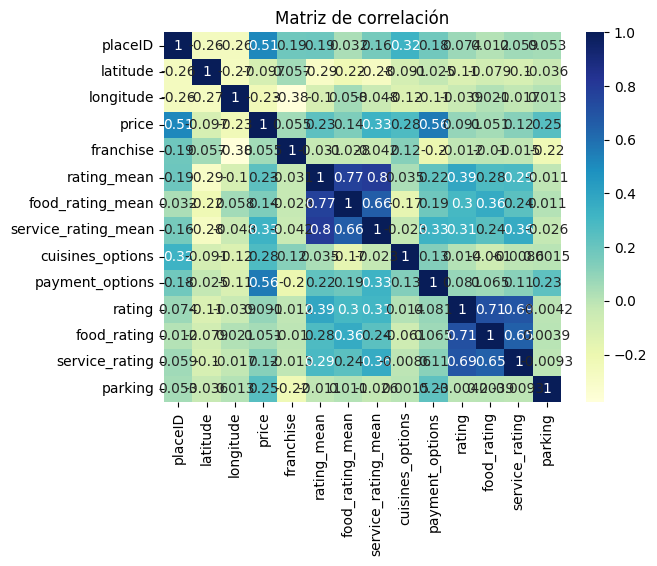

In [ ]:
# Matriz de correlación
corr = rest_rating.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="YlGnBu")
plt.title("Matriz de correlación")
plt.show()

### Análisis Nulls y Outliers

In [ ]:
ctgv = ctg_viz.CTGViz(rest_rating)

ctgv.check_data_completeness_dafneelizabethzepedagonzalez()

In [ ]:
varc, vard = ctgv.vars_categorization()

In [ ]:
varc

['placeID',
 'latitude',
 'longitude',
 'rating_mean',
 'food_rating_mean',
 'service_rating_mean']

In [ ]:
vard

['the_geom_meter',
 'name',
 'address',
 'city',
 'state',
 'country',
 'fax',
 'zip',
 'alcohol',
 'smoking_area',
 'dress_code',
 'accessibility',
 'price',
 'url',
 'Rambience',
 'franchise',
 'area',
 'other_services',
 'cuisines_options',
 'payment_options',
 'userID',
 'rating',
 'food_rating',
 'service_rating',
 'parking_lot',
 'parking']

In [ ]:
len(rest_rating.parking.unique())

2

In [46]:
#Variables unarias
for col in rest_rating.columns:
    if len(rest_rating[col].unique()) == 1:
        print(f"{col}:      {rest_rating[col].unique()[0]}")

fax:      ?
